# Web app for testing Emotion detection by CNN

Team: Pierre Bordeau, Nathan Chandanson, Rémi Moshfeghi

Github repo with training code and the README explaining the results: https://github.com/pierrebrd/RO11_Emotion_CNN/

## Instructions:

First, choose runtime to execute the code (CPU or GPU both work).

Execute the first cells of code, and then you are ready to record your voice, see your spectrogram and get a prediction of your emotion!

The CNNs were trained on a German database (EmoDB) so try to speak german ;)


## Depencies installation

The following lines install the necessary libraries and download the weights from the team's github repo

In [ ]:
# Install dependencies
!pip install ipywebrtc
# Download weights for ResNet18 finetuned
!wget https://github.com/pierrebrd/RO11_Emotion_CNN/raw/refs/heads/main/resnet18_emotion.pth
# Download weights for the fully custom CNN
!wget https://github.com/pierrebrd/RO11_Emotion_CNN/raw/refs/heads/main/fromScratch_trained.pth
# Download weights for the dilated custom CNN
!wget https://github.com/pierrebrd/RO11_Emotion_CNN/raw/refs/heads/main/fromScratchDilated_trained.pth

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.7/260.7 kB 3.0 MB/s eta 0:00:00
--2026-09-29 07:35:52--  https://github.com/pierrebrd/RO11_Emotion_CNN/raw/refs/heads/main/resnet18_emotion.pth
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/pierrebrd/RO11_Emotion_CNN/refs/heads/main/resnet18_emotion.pth [following]
--2026-09-29 07:35:53--  https://raw.githubusercontent.com/pierrebrd/RO11_Emotion_CNN/refs/heads/main/resnet18_emotion.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 44800971 (43M) [application/octet-stream]
Saving to: ‘resnet18_emotion.pth’

resnet18_emotion.pt 100%[=============

## Code execution to prepare the models and the audio recording

In [ ]:
# @title
# Imports
import pandas as pd
import torch
import torch.nn as nn
import torchaudio
import torchvision.models as models
import torchaudio.transforms as T
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from ipywebrtc import AudioRecorder, CameraStream
import google.colab.output as colab_output
import librosa.display # for log axis on spectrogram

# We make them audio 3s long by padding or truncating them, as it was done for the training

def truncate_or_pad(x, target_len):
  current_len = x.shape[1]

  if isinstance(x, torch.Tensor):
    if current_len > target_len:
      return x[:, :target_len]
    else:
      pad_size = target_len - current_len
      pad_shape = (1,pad_size)
      padding = torch.zeros(pad_shape, dtype=x.dtype, device=x.device)
      return torch.cat([x, padding], dim=1)

def compute_spectrogram(file_path):
    waveform, sample_rate = torchaudio.load(file_path)
    waveform = truncate_or_pad(waveform, sample_rate*3)

    # 25ms windows every 10ms
    window_length = int(sample_rate * 0.025) # 25ms frames
    hop_length = int(sample_rate * 0.010)    # 10ms hop

    mel_transform = T.MelSpectrogram(
        sample_rate=sample_rate,
        win_length=window_length,
        hop_length=hop_length,
        n_mels=64
    )

    amp_to_db = T.AmplitudeToDB(stype="power", top_db=80)

    spec_db = amp_to_db(mel_transform(waveform)).squeeze(0)

    return spec_db

# Function to create grayscale spectrogram image for ResNet18
def make_spectrogram_image(recording_spectrogram, output_path):
    figure = plt.figure(figsize=(2.24, 2.24), dpi=100)
    axes = figure.add_axes([0, 0, 1, 1])
    axes.imshow(
        recording_spectrogram.numpy(),
        origin="lower",
        aspect="auto",
        cmap="gray",
    )
    axes.axis("off")
    figure.savefig(
        output_path,
        dpi=100,
        pad_inches=0,
    )
    plt.close(figure)


# From Scratch CNN
# @title
class fromScratch(nn.Module):
    def __init__(self, in_channels=1):  # in_channels = 1 because we deal with gray scale images
        super().__init__()

        # we could have been making a helper function so that we don't have to define all four blocks by hand but since it's our first time using torch I think it helps understanding the NN's architecture
        self.block1 = nn.Sequential(  # first block : going from 1 channel to 32
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=32,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block2 = nn.Sequential(  # second block : going from 32 channels to 64
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=64,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block3 = nn.Sequential(  # third block : going from 64 channels to 128
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(num_features=128),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=128,
                out_channels=128,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(num_features=128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block4 = nn.Sequential(  # fourth block : going from 128 channels to 256
            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=256,
                out_channels=256,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))  # global average pooling : this performs an average on each of the 256 small images produced, so that we go from 256 small matrices to 256 digits
        self.dropout = nn.Dropout(p=0.5)  # during training, half of the 256 values produced (chosen randomly) will be set to zero, which helps avoid overfitting
        self.fc = nn.Linear(in_features=256, out_features=7)  # going from 256 values to 7, since our goal is to classify each audio in 7 emotions


    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# Dilated CNN
class fromScratchDilated(nn.Module):
    def __init__(self, in_channels=1):  # in_channels = 1 because we deal with gray scale images
        super().__init__()

        # we could have been making a helper function so that we don't have to define all four blocks by hand but since it's our first time using torch I think it helps understanding the NN's architecture
        self.block1 = nn.Sequential(  # first block : going from 1 channel to 32
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=2,
                dilation=2,
                bias=False
            ),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=32,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=2,
                dilation=2,
                bias=False
            ),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block2 = nn.Sequential(  # second block : going from 32 channels to 64
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=2,
                dilation=2,
                bias=False
            ),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=64,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=2,
                dilation=2,
                bias=False
            ),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block3 = nn.Sequential(  # third block : going from 64 channels to 128
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                stride=1,
                padding=2,
                dilation=2,
                bias=False
            ),
            nn.BatchNorm2d(num_features=128),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=128,
                out_channels=128,
                kernel_size=3,
                stride=1,
                padding=2,
                dilation=2,
                bias=False
            ),
            nn.BatchNorm2d(num_features=128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block4 = nn.Sequential(  # fourth block : going from 128 channels to 256
            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                stride=1,
                padding=2,
                dilation=2,
                bias=False
            ),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=256,
                out_channels=256,
                kernel_size=3,
                stride=1,
                padding=2,
                dilation=2,
                bias=False
            ),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))  # global average pooling : this performs an average on each of the 256 small images produced, so that we go from 256 small matrices to 256 digits
        self.dropout = nn.Dropout(p=0.5)  # during training, half of the 256 values produced (chosen randomly) will be set to zero, which helps avoid overfitting
        self.fc = nn.Linear(in_features=256, out_features=7)  # going from 256 values to 7, since our goal is to classify each audio in 7 emotions


    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# Recorder setup

colab_output.enable_custom_widget_manager()
camera = CameraStream(constraints={'audio': True,'video':False})
recorder = AudioRecorder(stream=camera)



# Inference

To test the inference, you can now record your own voice by executing the following cells.

- The first one creates the recording

- The second one converts it to .wav format, make it 3s and finally create a spectrogram for it.

- Finally, the last cell will give you the results of the emotion detected by our CNNs !


## Recorder

**You might need to restart the cell multiple times to set your microphone permission**

**After that, the first recording might be of bad quality : click the record button again to get a new recording, without executing the cell again**

**The cell have to be executed again each time you want a new recording**

In [ ]:
recorder

AudioRecorder(audio=Audio(value=b'', format='webm'), stream=CameraStream(constraints={'audio': True, 'video': …

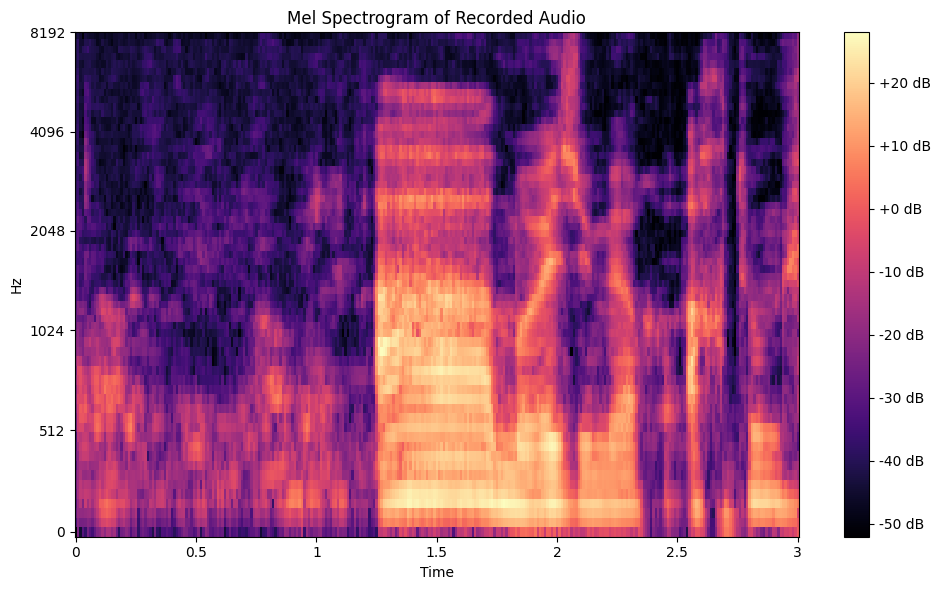

In [ ]:
# @title
# Writing the audio
with open('recording.webm', 'wb') as f:
    f.write(recorder.audio.value)

# Convert the audio to a 16Khz wav
!ffmpeg -i recording.webm -ac 1 -ar 16000 -f wav my_recording.wav -y -hide_banner -loglevel panic

recording_spectrogram = compute_spectrogram("my_recording.wav")

# Load the audio to get the sample rate
_, sample_rate = torchaudio.load("my_recording.wav")
# hop_length defined in compute_spectrogram
hop_length = int(sample_rate * 0.010)

plt.figure(figsize=(10, 6))

# specshow replaces plt.imshow to handle log frequency axis
librosa.display.specshow(
    recording_spectrogram.numpy(),
    sr=sample_rate,
    hop_length=hop_length,
    x_axis='time',
    y_axis='mel',      # This forces the Y-axis to display in a logarithmic Hz scale
    cmap='magma'
)

plt.title("Mel Spectrogram of Recorded Audio")
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.show()

## ResNet18 CNN prediction




=== ResNet18 with fine-tuned FC layer ===

 Input image created from your spectrogram:


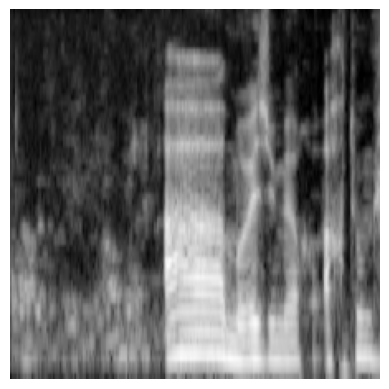


Predicted emotion: sadness

Emotion probabilities (sorted by percentage):
- sadness: 56.32%
- boredom: 14.26%
- disgust: 13.79%
- anger: 6.58%
- happiness: 6.13%
- neutral: 2.32%
- fear: 0.60%


In [ ]:
# @title
# ResNet18 CNN

# Import Model
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 7)
if not torch.cuda.is_available():
  model.load_state_dict(torch.load("resnet18_emotion.pth",map_location=torch.device('cpu'))["model_state_dict"])
  class_to_idx=torch.load("resnet18_emotion.pth",map_location=torch.device('cpu'))["class_to_idx"]
else:
  model.load_state_dict(torch.load("resnet18_emotion.pth")["model_state_dict"])
  class_to_idx=torch.load("resnet18_emotion.pth")["class_to_idx"]
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


# prepare the spectrogram image
make_spectrogram_image(recording_spectrogram, "spectrogram_resnet.png")
transform_spectrogram_resnet   = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

print("\n\n\n=== ResNet18 with fine-tuned FC layer ===")
print("\n Input image created from your spectrogram:")
plt.imshow(Image.open("spectrogram_resnet.png"))
plt.axis("off")
plt.show()

# Evaluate
# Explicitly convert the image to RGB to ensure 3 channels before applying transforms
input_image = Image.open("spectrogram_resnet.png").convert("RGB")
input = transform_spectrogram_resnet(input_image).unsqueeze(0).to(device)
output = model(input)

_, predicted_class_idx = torch.max(output, 1)

id2label = {i: emotion for emotion, i in class_to_idx.items()}
predicted_emotion = id2label[predicted_class_idx.item()]

print(f"\nPredicted emotion: {predicted_emotion}")

# Calculate probabilities and percentages
probabilities = torch.nn.functional.softmax(output, dim=1)[0]
percentages = {id2label[i]: f"{p.item()*100:.2f}%" for i, p in enumerate(probabilities)}

print("\nEmotion probabilities (sorted by percentage):")
sorted_percentages = sorted(percentages.items(), key=lambda item: float(item[1].strip('%')), reverse=True)

for emotion, percentage in sorted_percentages:
    print(f"- {emotion}: {percentage}")

## From-scratch CNN prediction

In [ ]:
# @title
# From-scratch CNN

# Import Model
model = fromScratch(in_channels=1).to(device)
if not torch.cuda.is_available():
  model.load_state_dict(torch.load("fromScratch_trained.pth",map_location=torch.device('cpu')))
else:
  model.load_state_dict(torch.load("fromScratch_trained.pth"))
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("=== From-scratch CNN ===")

# Evaluate
input = recording_spectrogram.unsqueeze(0).unsqueeze(0).float().to(device)
output = model(input)

_, predicted_class_idx = torch.max(output, 1)

predicted_emotion = id2label[predicted_class_idx.item()]

print(f"\nPredicted emotion: {predicted_emotion}")

# Calculate probabilities and percentages
probabilities = torch.nn.functional.softmax(output, dim=1)[0]
percentages = {id2label[i]: f"{p.item()*100:.2f}%" for i, p in enumerate(probabilities)}

print("\nEmotion probabilities (sorted by percentage):")
sorted_percentages = sorted(percentages.items(), key=lambda item: float(item[1].strip('%')), reverse=True)

for emotion, percentage in sorted_percentages:
    print(f"- {emotion}: {percentage}")

=== From-scratch CNN ===

Predicted emotion: boredom

Emotion probabilities (sorted by percentage):
- boredom: 99.15%
- anger: 0.56%
- happiness: 0.12%
- neutral: 0.09%
- sadness: 0.06%
- disgust: 0.02%
- fear: 0.00%


## Dilated from-scratch CNN prediction

In [ ]:
# @title
# From-scratch CNN

# Import Model
model = fromScratchDilated(in_channels=1).to(device)
if not torch.cuda.is_available():
  model.load_state_dict(torch.load("fromScratchDilated_trained.pth",map_location=torch.device('cpu')))
else:
  model.load_state_dict(torch.load("fromScratchDilated_trained.pth"))
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("=== Dilated from-scratch CNN ===")

# Evaluate
input = recording_spectrogram.unsqueeze(0).unsqueeze(0).float().to(device)
output = model(input)

_, predicted_class_idx = torch.max(output, 1)

predicted_emotion = id2label[predicted_class_idx.item()]

print(f"\nPredicted emotion: {predicted_emotion}")

# Calculate probabilities and percentages
probabilities = torch.nn.functional.softmax(output, dim=1)[0]
percentages = {id2label[i]: f"{p.item()*100:.2f}%" for i, p in enumerate(probabilities)}

print("\nEmotion probabilities (sorted by percentage):")
sorted_percentages = sorted(percentages.items(), key=lambda item: float(item[1].strip('%')), reverse=True)

for emotion, percentage in sorted_percentages:
    print(f"- {emotion}: {percentage}")

=== Dilated from-scratch CNN ===

Predicted emotion: boredom

Emotion probabilities (sorted by percentage):
- boredom: 94.34%
- anger: 4.81%
- sadness: 0.66%
- neutral: 0.13%
- disgust: 0.03%
- happiness: 0.03%
- fear: 0.00%
